In [ ]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
os.environ['KERAS_BACKEND'] = 'tensorflow'
from keras.models import Sequential
from keras.layers import Dense, LSTM, Flatten, Conv2D
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split, KFold

2026-08-10 11:07:42.125118: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-08-10 11:07:42.257762: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1786356462.312009   42136 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1786356462.325876   42136 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-08-10 11:07:42.424749: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

In [2]:
# Set font type to Arial
plt.rcParams['font.family'] = 'Arial'

In [3]:
def LongShortTermMemoryModel(L1=160, L2=20):
    
    """
    
    parent_model builds an LSTM model with paramters that work accross all functional fitness models in the Fit4Function study. 
    L1 and L2 define the sizes of the model two layers. 
    
    """
    model = Sequential()
    model.add(LSTM(L1, return_sequences=True, input_shape=(8, 20)))
    model.add(LSTM(L2, return_sequences=False))
    model.add(Dense(units=1))
    model.compile(loss='mean_squared_error', optimizer='adam', metrics=['mae'])

    return model

def Perceptron(L1=160):

    model = Sequential()
    model.add(Flatten(input_shape=(8, 20)))
    model.add(Dense(L1))
    model.add(Dense(L1))
    model.add(Dense(units=1))
    model.compile(loss='mean_squared_error', optimizer='adam', metrics=['mae'])
    return model

def CNN(L1=160):
    model = Sequential()
    # Add a Conv2D layer with filters that convolve along the height (8) while preserving the width (20)
    model.add(Conv2D(L1, (8, 1), activation='relu', input_shape=(8, 20, 1)))
    # Flatten the output to feed into Dense layers
    model.add(Flatten())
    # Output layer with a single unit for continuous output
    model.add(Dense(1))
    model.compile(loss='mean_squared_error', optimizer='adam', metrics=['mae'])
    return model

In [4]:
def AA_hotencoding(variant):
    
    """
    
    AA_hotencoding takes an amino acid sequence 'variant' of an arbitrary length, 
    and returns a 20xlength one-hot encoding matrix 'onehot_encoded'.   
    
    """
       
    AAs = 'ARNDCQEGHILKMFPSTWYV'
    encoding_length = len(AAs)
    variant_length = len(variant)

    # Define a mapping of chars to integers
    char_to_int = dict((c, i) for i, c in enumerate(AAs))
    int_to_char = dict((i, c) for i, c in enumerate(AAs))

    # Encode input data 
    integer_encoded = [char_to_int[char] for i, char in enumerate(variant) if i <variant_length]
    
    # Start one-hot-encoding
    onehot_encoded = list()
    
    for value in integer_encoded:
        letter = [0 for _ in range(encoding_length)]
        letter[value] = 1
        onehot_encoded.append(letter)
                
    return onehot_encoded

In [5]:
# Starting from read count to perform ablation study

# define numerator and denominator files to calculate enrichment
df_numerator = pd.read_excel("data/Excel/third_round/pre_encapsulation_variant_count.xlsx")
df_denominator = pd.read_excel("data/Excel/third_round/post_encapsulation_variant_count.xlsx")

In [6]:
# Calculate the sum of all integers in the column "variant_count"
total_variant_count_denominator = df_denominator['variant_count'].sum()
total_variant_count_numerator = df_numerator['variant_count'].sum()

# merging both dataframes
merged_df = pd.merge(df_denominator, df_numerator, on='variant', suffixes=('_denominator', '_numerator'))

In [7]:
# Introduce read count cutoff
merged_df = merged_df.loc[merged_df["variant_count_denominator"] >= 32]
merged_df = merged_df.loc[merged_df["variant_count_numerator"] >= 32]

In [8]:
# Normalize the "variant_count" column
merged_df[f'variant_count_denominator_normalized'] = merged_df[f"variant_count_denominator"] / total_variant_count_denominator
merged_df[f'variant_count_numerator_normalized'] = merged_df[f"variant_count_numerator"] / total_variant_count_numerator

# Create a new column for the division result
merged_df[f'enrichment_score'] = merged_df[f'variant_count_numerator_normalized'] / merged_df[f'variant_count_denominator_normalized']

# log2 transform the enrichment score for each read count divisor
merged_df[f'log2_enrichment_score'] = merged_df[f'enrichment_score'].apply(lambda x: np.log2(x))

from Bio.Seq import Seq

# Function to translate DNA sequence to amino acid sequence
def translate_dna_to_protein(dna_seq):
    dna_seq_obj = Seq(dna_seq)
    protein_seq = str(dna_seq_obj.translate())
    return protein_seq

# Translate the 'variant' column and save in a new column 'amino_acid_sequence'
merged_df['amino_acid_sequence'] = merged_df['variant'].apply(translate_dna_to_protein)

# Get rid of variants with stop codons
merged_df = merged_df[~merged_df.astype(str).apply(lambda row: row.str.contains(r"\*").any(), axis=1)]
merged_df = merged_df.loc[merged_df["variant_length_denominator"]==24]

/home/marinaluchner/anaconda3/envs/modelling_env/lib/python3.12/site-packages/Bio/Seq.py:2879: BiopythonWarning: Partial codon, len(sequence) not a multiple of three. Explicitly trim the sequence or add trailing N before translation. This may become an error in future.
  warnings.warn(


In [9]:
# GOAL I would like to take the log2 of the average enrichment score

# Remove rational designs from the dataset
rational_motifs = ["YP*L", "PP*Y", "FPIV", "PLPPV", "L**L", "KFERQ", "PSAP", "PTAP"]

import re

# Function to check if sequence contains any of the motifs
def contains_motifs(sequence, motifs):
    return any(motif for motif in motifs if contains_wildcard_motif(sequence, motif))

def contains_wildcard_motif(sequence, motif):
    # Convert the motif to a regex pattern, replacing '*' with '.'
    regex_pattern = motif.replace("*", ".")
    # Search for the pattern in the sequence
    return re.search(regex_pattern, sequence) is not None

merged_df = merged_df[~merged_df['amino_acid_sequence'].apply(lambda seq: contains_motifs(seq, rational_motifs))]


In [10]:
# GOAL train test split
# 80% training, 10% validation, 10% test
train_size = 1619
test_size = 202

# Split the data into training and test sets
train, test = np.split(merged_df.sample(frac=1), [train_size])

/home/marinaluchner/anaconda3/envs/modelling_env/lib/python3.12/site-packages/numpy/core/fromnumeric.py:59: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [11]:
train_y = {}
test_y = {}
noise_levels = [0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0]

for noise in noise_levels:

    train_y[f"{noise}"] =  np.asarray(train["log2_enrichment_score"] + np.random.normal(train["log2_enrichment_score"], abs(train["log2_enrichment_score"]) * noise, size=train.shape[0]))
    test_y[f"{noise}"] = np.asarray(test["log2_enrichment_score"] + np.random.normal(test["log2_enrichment_score"], abs(test["log2_enrichment_score"]) * noise, size=test.shape[0]))
    # GOAL one hot encoding of the amino acid sequences
    train_x = np.asarray([AA_hotencoding(variant) for variant in train["amino_acid_sequence"]])
    test_x = np.asarray([AA_hotencoding(variant) for variant in test["amino_acid_sequence"]])

In [12]:
# Define the number of folds
kf = KFold(n_splits=10, shuffle=True, random_state=42)

In [13]:
models = {}

for noise in noise_levels:
    # Perform cross-validation for each model
    models[f'FNN_{noise}'] = [Perceptron, noise]
    models[f'LSTM_{noise}'] = [LongShortTermMemoryModel, noise]
    models[f'CNN_{noise}'] = [CNN, noise]
pearson_results = {model_name: [] for model_name in models.keys()}

In [14]:
for model_name, model_params in models.items():
    model_func = model_params[0]
    noise = model_params[1]

    fold = 1
    fold_results = []

    train_y_current = train_y[f"{noise}"]

    for train_index, val_index in kf.split(train_x):
            print(f"Training fold {fold} for {model_name}...")
            
            # Split the data into training and validation sets
            X_train, X_val = train_x[train_index], train_x[val_index]
            y_train, y_val = train_y_current[train_index], train_y_current[val_index]
            
            # Create the model
            model = model_func()
            
            # Train the model
            model.fit(
                X_train,
                y_train,
                validation_data=(X_val, y_val),
                epochs=50,
                batch_size=500,
                verbose=0
            )
            
            # Evaluate the model on the validation set
            val_loss, val_mae = model.evaluate(X_val, y_val, verbose=0)

            # Store the results for the current model
            y_pred = model.predict(X_val)
            y_pred = np.reshape(y_pred, (1,y_pred.shape[0]))[0]
            pearson_corr = np.corrcoef(y_val, y_pred)[0, 1]
            pearson_results[model_name].append(pearson_corr)
            print(f"Pearson for {model_name} {fold}: {pearson_results[model_name]}")
            
            fold += 1

/home/marinaluchner/anaconda3/envs/modelling_env/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
W0000 00:00:1786356541.573260   42136 gpu_device.cc:2344] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Training fold 1 for FNN_0...
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Pearson for FNN_0 1: [0.5594099842227187]
Training fold 2 for FNN_0...
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Pearson for FNN_0 2: [0.5594099842227187, 0.6358154226506751]
Training fold 3 for FNN_0...
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Pearson for FNN_0 3: [0.5594099842227187, 0.6358154226506751, 0.6429246685680536]
Training fold 4 for FNN_0...
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Pearson for FNN_0 4: [0.5594099842227187, 0.6358154226506751, 0.6429246685680536, 0.5485830943780567]
Training fold 5 for FNN_0...
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Pearson for FNN_0 5: [0.5594099842227187, 0.6358154226506751, 0.6429246685680536, 0.5485830943780567, 0.6163401935684026]
Training fold 6 for FNN_0...
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Pearson for FNN_0 6: [0.5594099842227187, 0.6358154226506751, 0.6429246685680536, 0.5485830943780567, 0.6163401935684026, 0.6874964748698027]
Training fold 7 for FNN_0...
6/6 ━━━━━━━━━━━━━━

/home/marinaluchner/anaconda3/envs/modelling_env/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Pearson for LSTM_0 1: [0.6158618786249289]
Training fold 2 for LSTM_0...
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Pearson for LSTM_0 2: [0.6158618786249289, 0.6822690778811603]
Training fold 3 for LSTM_0...
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Pearson for LSTM_0 3: [0.6158618786249289, 0.6822690778811603, 0.6284268231602737]
Training fold 4 for LSTM_0...
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Pearson for LSTM_0 4: [0.6158618786249289, 0.6822690778811603, 0.6284268231602737, 0.598559392758742]
Training fold 5 for LSTM_0...
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Pearson for LSTM_0 5: [0.6158618786249289, 0.6822690778811603, 0.6284268231602737, 0.598559392758742, 0.6925885106232104]
Training fold 6 for LSTM_0...
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Pearson for LSTM_0 6: [0.6158618786249289, 0.6822690778811603, 0.6284268231602737, 0.598559392758742, 0.6925885106232104, 0.7640011255272403]
Training fold 7 for LSTM_0...
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step

/home/marinaluchner/anaconda3/envs/modelling_env/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Pearson for CNN_0 1: [0.6217852077497161]
Training fold 2 for CNN_0...
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
Pearson for CNN_0 2: [0.6217852077497161, 0.6614647246450743]
Training fold 3 for CNN_0...
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Pearson for CNN_0 3: [0.6217852077497161, 0.6614647246450743, 0.6698641541670444]
Training fold 4 for CNN_0...
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Pearson for CNN_0 4: [0.6217852077497161, 0.6614647246450743, 0.6698641541670444, 0.5968679359182213]
Training fold 5 for CNN_0...
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Pearson for CNN_0 5: [0.6217852077497161, 0.6614647246450743, 0.6698641541670444, 0.5968679359182213, 0.6370960762009182]
Training fold 6 for CNN_0...
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Pearson for CNN_0 6: [0.6217852077497161, 0.6614647246450743, 0.6698641541670444, 0.5968679359182213, 0.6370960762009182, 0.7402569331552735]
Training fold 7 for CNN_0...
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Pearson 

In [15]:
train_y = {}
test_y = {}

for noise in noise_levels:
  
    # GOAL one hot encoding of the amino acid sequences

    train_x = np.asarray([AA_hotencoding(variant) for variant in merged_df["amino_acid_sequence"]])
    train_y[f"{noise}"] =  np.asarray(merged_df["log2_enrichment_score"] + np.random.normal(merged_df["log2_enrichment_score"], abs(merged_df["log2_enrichment_score"]) * noise, size=merged_df.shape[0]))

In [16]:
# GOAL: Train a Linear Regression model to predict the log2_averaged_enrichment_score from the one-hot encoded amino acid sequences
for noise in noise_levels:

    train_y_current = train_y[f"{noise}"]
    fold_results = []
    fold = 1
    
    for train_index, val_index in kf.split(train_x):
        print(f"Training fold {fold}...")
        
        # Split the data into training and validation sets
        X_train, X_val = train_x[train_index], train_x[val_index]
        y_train, y_val = train_y_current[train_index], train_y_current[val_index]

        # Reshape the 3D arrays into 2D arrays
        X_train_reshaped = X_train.reshape(X_train.shape[0], -1)
        X_val_reshaped = X_val.reshape(X_val.shape[0], -1)
        
        # Train the model
        model = LinearRegression()
        model.fit(X_train_reshaped, y_train)
        y_pred = model.predict(X_val_reshaped)

        # Calculate pearson correlation coefficient
        corrcoef = np.corrcoef(y_val, y_pred)[0, 1]
        print(f"Pearson for LR_{noise} fold {fold}: {corrcoef}")
        # Append the results to the fold_results list
        fold_results.append(corrcoef)
        fold += 1

    pearson_results[f'LR_{noise}'] = fold_results    

Training fold 1...
Pearson for LR_0 fold 1: 0.6001895773482742
Training fold 2...
Pearson for LR_0 fold 2: 0.6600617425489067
Training fold 3...
Pearson for LR_0 fold 3: 0.43635303033460465
Training fold 4...
Pearson for LR_0 fold 4: 0.6543776665017489
Training fold 5...
Pearson for LR_0 fold 5: 0.5674756403293351
Training fold 6...
Pearson for LR_0 fold 6: 0.541456550792318
Training fold 7...
Pearson for LR_0 fold 7: 0.5558929905682541
Training fold 8...
Pearson for LR_0 fold 8: 0.20866362688763784
Training fold 9...
Pearson for LR_0 fold 9: 0.702343593992076
Training fold 10...
Pearson for LR_0 fold 10: 0.6239443161810875
Training fold 1...
Pearson for LR_0.5 fold 1: 0.5936231015594644
Training fold 2...
Pearson for LR_0.5 fold 2: 0.6287295361455731
Training fold 3...
Pearson for LR_0.5 fold 3: 0.4449547019944697
Training fold 4...
Pearson for LR_0.5 fold 4: 0.617999998256322
Training fold 5...
Pearson for LR_0.5 fold 5: 0.5545404973249394
Training fold 6...
Pearson for LR_0.5 fold 6

In [17]:
# Set font properties
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 24

In [18]:
from statistics import mean

averages = {
    key: mean(values)
    for key, values in pearson_results.items()
}
errors = {
    key: np.std(values)
    for key, values in pearson_results.items()
}

from collections import defaultdict

model_results = defaultdict(list)

model_errors = defaultdict(list)

for key, avg in averages.items():
    model, threshold = key.split("_")
    model_results[model].append((threshold, avg))

for key, error in errors.items():
    model, threshold = key.split("_")
    model_errors[model].append((threshold, error))

final = {}
final_errors = {}

for model, values in model_results.items():
    values.sort(key=lambda x: x[0])        # sort by threshold
    final[model] = [avg for _, avg in values]

for model, values in model_errors.items():
    values.sort(key=lambda x: x[0])        # sort by threshold
    final_errors[model] = [error for _, error in values]

final_lists = {k: [v for v in vals] for k, vals in final.items()}
final_error_lists = {k: [v for v in vals] for k, vals in final_errors.items()}

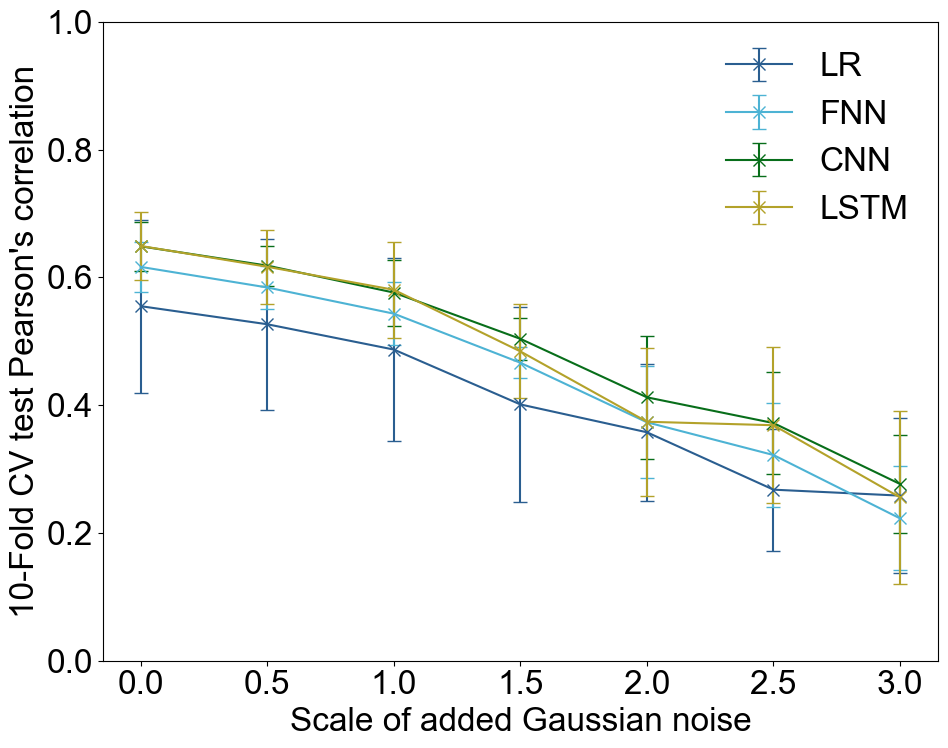

In [19]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors

# Paul Tol's Notes color scheme
colors = ['#4477AA','#66CCEE','#228833','#CCBB44','#EE6677','#AA3377','#BBBBBB']

# Function to darken a color
def darken_color(color, amount=0.1):
    c = mcolors.to_rgb(color)
    return mcolors.to_hex([max(0, c[i] - amount) for i in range(3)])

darker_colors = [darken_color(color) for color in colors]

# Desired order of models
model_order = ["LR", "FNN", "CNN", "LSTM"]

# Create scatter plot

plt.figure(figsize=(10, 8))

j = 0

# Plot average Pearson correlation coefficients
for model_name in model_order:
    if model_name in final_lists:
        plt.errorbar(
            noise_levels, 
            final_lists[model_name], 
            yerr=final_error_lists[model_name],
            capsize=5,
            color=darker_colors[j], 
        marker='x',  
        markersize=8,
        label=f'{model_name}'
    )
    j += 1

# Customize plot
plt.ylabel("10-Fold CV test Pearson's correlation", fontsize=24)
plt.xlabel('Scale of added Gaussian noise', fontsize=24)
plt.xticks(fontsize=24)
plt.yticks(fontsize=24)
plt.ylim(0, 1)

# Create custom legend
handles = [
    plt.Line2D([0], [0], marker='o', color='black', markerfacecolor='black', markersize=7, label='Individual'),
    plt.Line2D([0], [0], marker='x', color='black', markersize=7, label='Average')
]

# Show plot
plt.legend(frameon=False)
plt.tight_layout()
plt.savefig('plots/figure_4d.png')
plt.show()